In [2]:
import pandas as pd
from ISLP import load_data
import matplotlib.pyplot as plt
import seaborn as sns

# Завантаження датасету OJ
OJ = load_data('OJ')

# Виведення перших кількох рядків для перевірки
display(OJ.head())

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


### Dataset Features Description

Here is a breakdown of the variables in the `OJ` dataset:

*   **Purchase**: The brand of orange juice purchased (`CH` = Citrus Hill, `MM` = Minute Maid). This is our target variable.
*   **WeekofPurchase**: The week when the purchase occurred.
*   **StoreID**: The ID of the store where the purchase was made.
*   **PriceCH**: The regular price of Citrus Hill.
*   **PriceMM**: The regular price of Minute Maid.
*   **DiscCH**: The discount offered on Citrus Hill.
*   **DiscMM**: The discount offered on Minute Maid.
*   **SpecialCH**: Indicator if there was a special deal on Citrus Hill (1 = Yes, 0 = No).
*   **SpecialMM**: Indicator if there was a special deal on Minute Maid (1 = Yes, 0 = No).
*   **LoyalCH**: A numerical score representing the customer's brand loyalty to Citrus Hill.
*   **SalePriceMM**: The final sale price of Minute Maid (`PriceMM` - `DiscMM`).
*   **SalePriceCH**: The final sale price of Citrus Hill (`PriceCH` - `DiscCH`).
*   **PriceDiff**: The difference in final sale prices (`SalePriceMM` - `SalePriceCH`).
*   **Store7**: A categorical indicator of whether the purchase happened at Store 7 (`Yes` or `No`).
*   **PctDiscMM**: The percentage of the discount for Minute Maid.
*   **PctDiscCH**: The percentage of the discount for Citrus Hill.
*   **ListPriceDiff**: The difference in regular list prices (`PriceMM` - `PriceCH`).
*   **STORE**: An alternative store ID variable (groups the purchases into 5 possible stores).

In [20]:
OJ['StoreID'].unique()

array([1, 7, 2, 3, 4])

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Purchase        1070 non-null   category
 1   WeekofPurchase  1070 non-null   int64   
 2   StoreID         1070 non-null   int64   
 3   PriceCH         1070 non-null   float64 
 4   PriceMM         1070 non-null   float64 
 5   DiscCH          1070 non-null   float64 
 6   DiscMM          1070 non-null   float64 
 7   SpecialCH       1070 non-null   int64   
 8   SpecialMM       1070 non-null   int64   
 9   LoyalCH         1070 non-null   float64 
 10  SalePriceMM     1070 non-null   float64 
 11  SalePriceCH     1070 non-null   float64 
 12  PriceDiff       1070 non-null   float64 
 13  Store7          1070 non-null   category
 14  PctDiscMM       1070 non-null   float64 
 15  PctDiscCH       1070 non-null   float64 
 16  ListPriceDiff   1070 non-null   float64 
 17  STORE      

,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
count,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,254.381308,3.959813,1.867421,2.085411,0.051860,0.123364,0.147664,0.161682,0.565782,1.962047,1.815561,0.146486,0.059298,0.027314,0.217991,1.630841
std,15.558286,2.308984,0.101970,0.134386,0.117474,0.213834,0.354932,0.368331,0.307843,0.252697,0.143384,0.271563,0.101760,0.062232,0.107535,1.430387
min,227.000000,1.000000,1.690000,1.690000,0.000000,0.000000,0.000000,0.000000,0.000011,1.190000,1.390000,-0.670000,0.000000,0.000000,0.000000,0.000000
25%,240.000000,2.000000,1.790000,1.990000,0.000000,0.000000,0.000000,0.000000,0.325257,1.690000,1.750000,0.000000,0.000000,0.000000,0.140000,0.000000
50%,257.000000,3.000000,1.860000,2.090000,0.000000,0.000000,0.000000,0.000000,0.600000,2.090000,1.860000,0.230000,0.000000,0.000000,0.240000,2.000000
75%,268.000000,7.000000,1.990000,2.180000,0.000000,0.230000,0.000000,0.000000,0.850873,2.130000,1.890000,0.320000,0.112676,0.000000,0.300000,3.000000
max,278.000000,7.000000,2.090000,2.290000,0.500000,0.800000,1.000000,1.000000,0.999947,2.290000,2.090000,0.640000,0.402010,0.252688,0.440000,4.000000



-----------------------------------

Target Variable Distribution:
Purchase
CH    0.61028
MM    0.38972
Name: proportion, dtype: float64


/var/folders/nk/7z1ywx_15gq_crc3996dd4vm0000gn/T/ipykernel_95173/2354630104.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Purchase', data=OJ, palette='Set2')


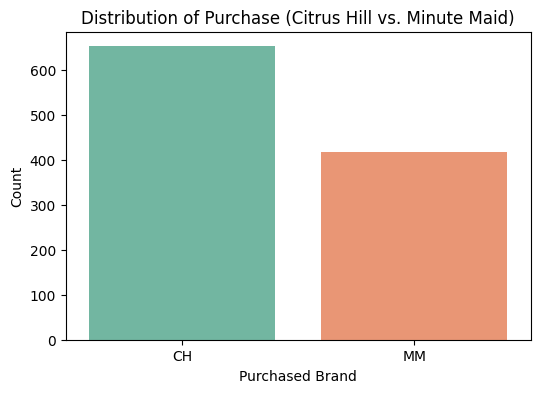

In [3]:
# Display basic information about the dataset (columns, types, non-null counts)
print("Dataset Info:")
OJ.info()
print("\n-----------------------------------\n")

# Display descriptive statistics for numerical columns
print("Descriptive Statistics:")
display(OJ.describe())
print("\n-----------------------------------\n")

# Check the distribution of the target variable 'Purchase'
print("Target Variable Distribution:")
print(OJ['Purchase'].value_counts(normalize=True))

# Plot the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Purchase', data=OJ, palette='Set2')
plt.title('Distribution of Purchase (Citrus Hill vs. Minute Maid)')
plt.xlabel('Purchased Brand')
plt.ylabel('Count')
plt.show()

In [4]:
# Cell 1: (a) Split the data
from sklearn.model_selection import train_test_split
import pandas as pd
from ISLP import load_data

# Load data and encode categorical variables (Store7)
OJ = load_data('OJ')
X = pd.get_dummies(OJ.drop(columns=['Purchase']), drop_first=True)
y = OJ['Purchase']

# Create a training set of exactly 800 observations
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=800, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 800
Test set size: 270


In [21]:
# Cell 2: (b) Fit tree and calculate training error
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Fit the unpruned tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict on training data and calculate error rate (1 - accuracy)
train_pred = clf.predict(X_train)
train_error = 1 - accuracy_score(y_train, train_pred)

print(f"Training Error Rate: {train_error:.4f}")

Training Error Rate: 0.0075


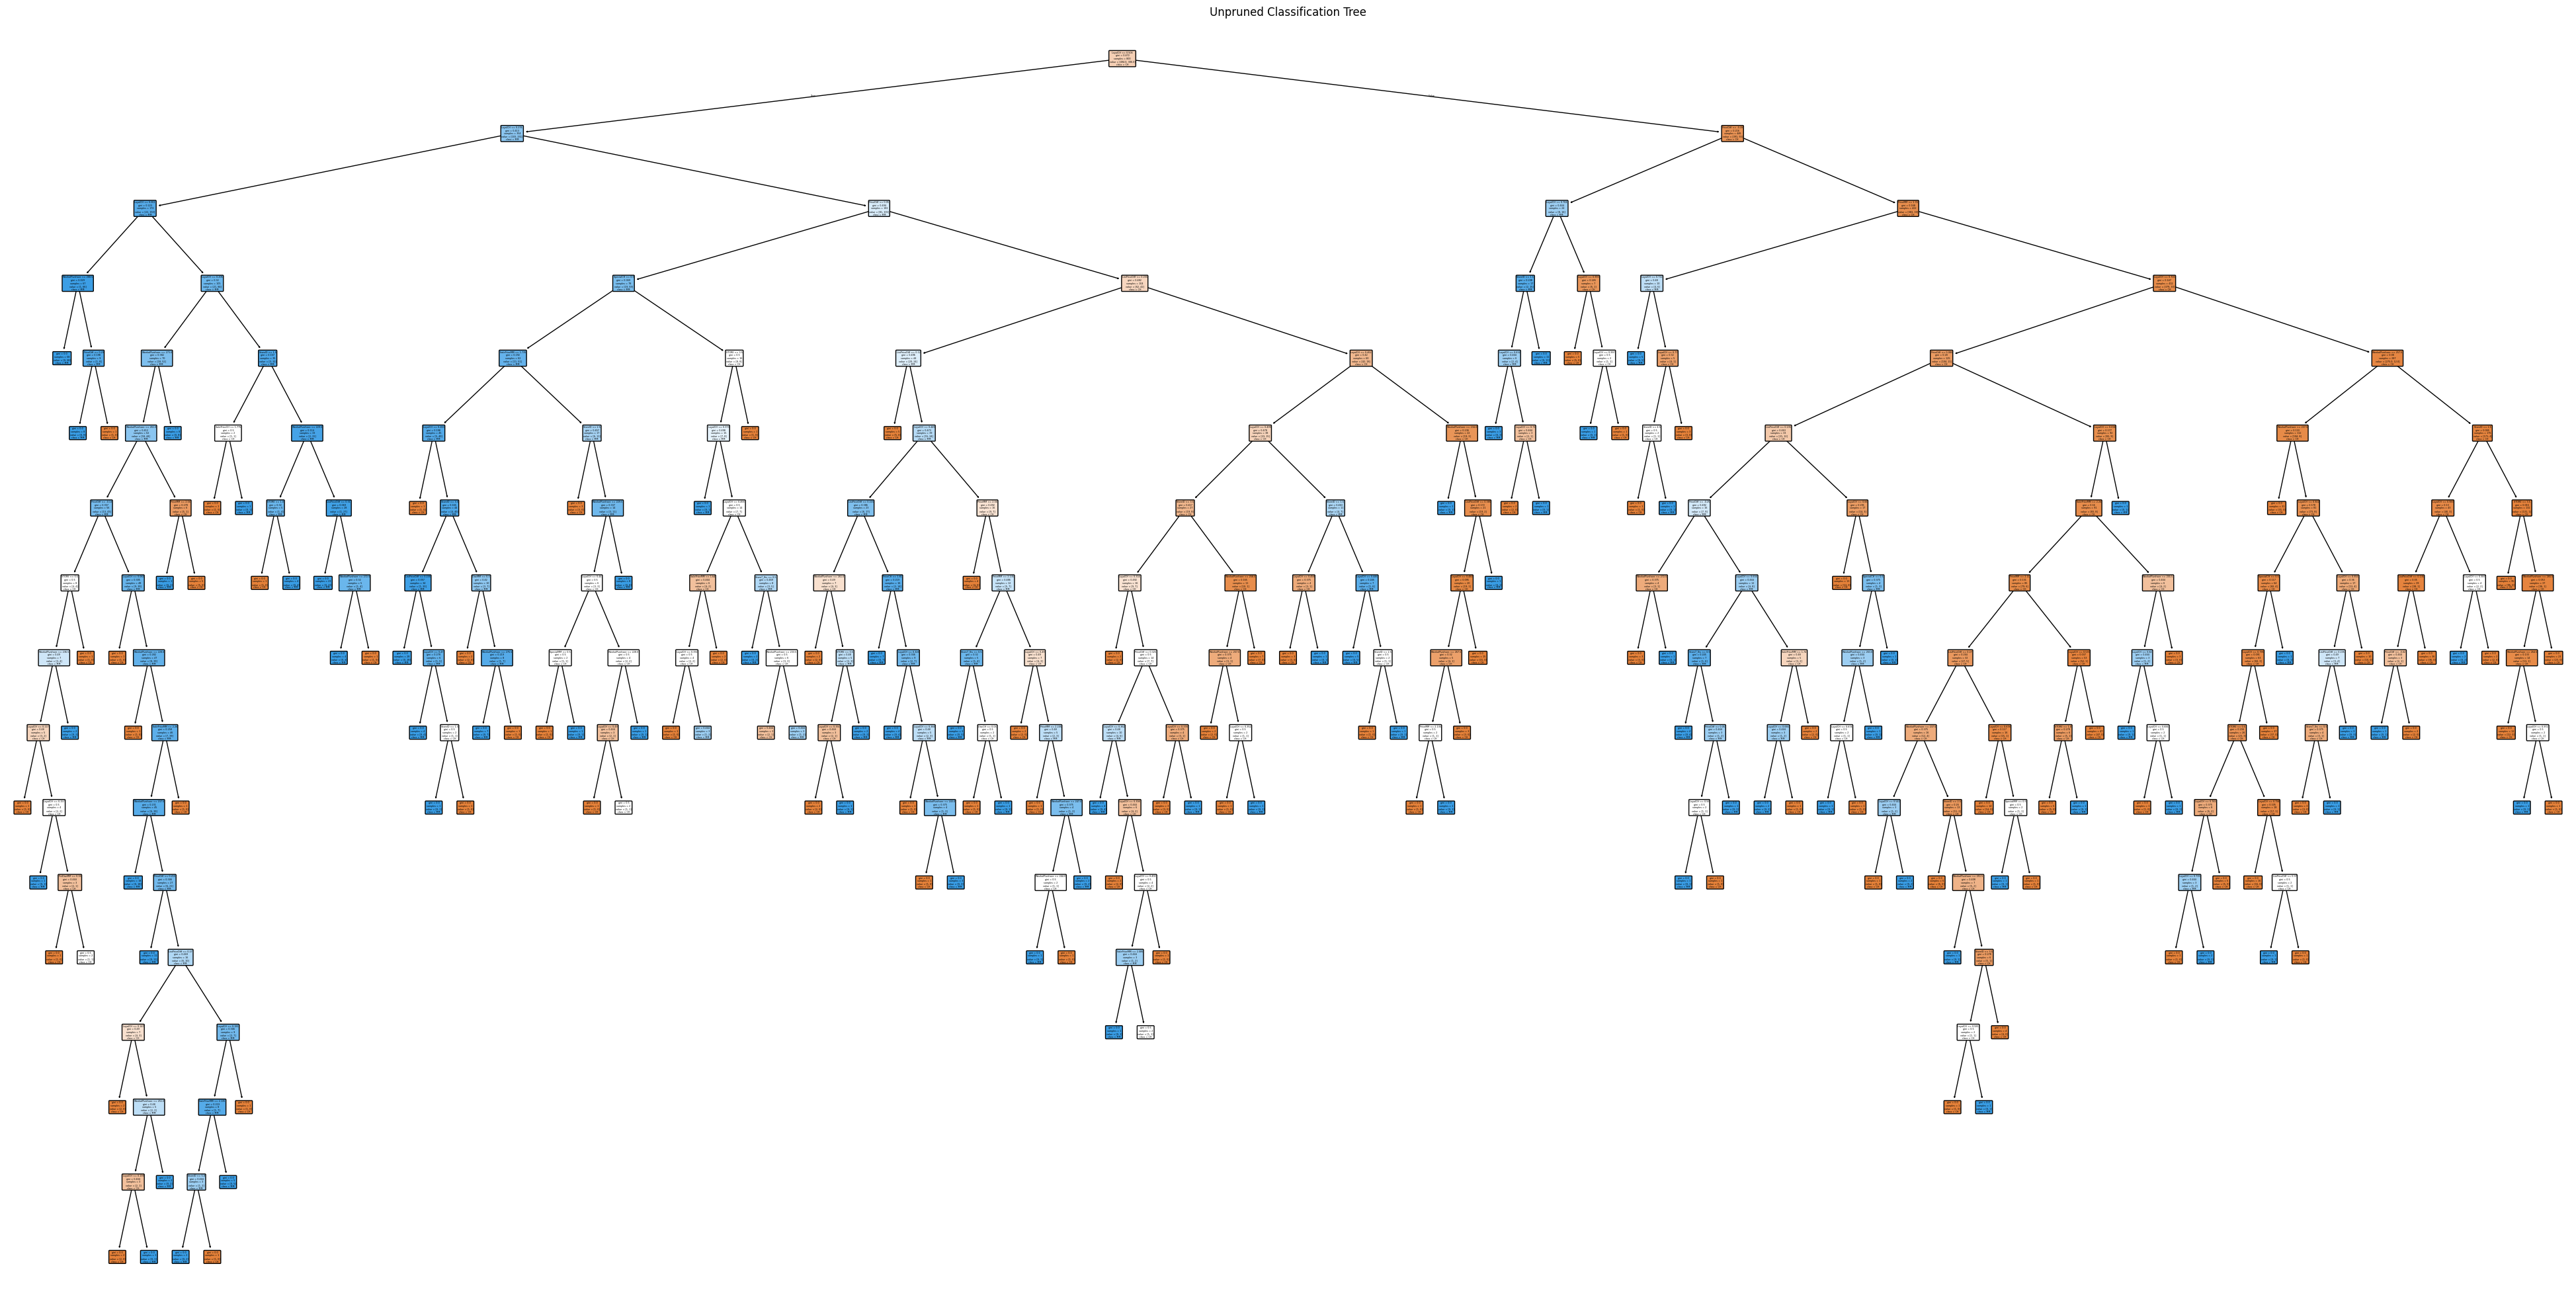

Number of terminal nodes: 163


In [16]:
# Cell 3: (c) Plot tree and count terminal nodes
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot the unpruned tree
plt.figure(figsize=(50, 25))
plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True, rounded=True)
plt.title("Unpruned Classification Tree")
plt.show()

# Get the number of terminal nodes (leaves)
n_leaves = clf.get_n_leaves()
print(f"Number of terminal nodes: {n_leaves}")


In [23]:
# Cell 4: (d) Text summary using export_text
from sklearn.tree import export_text

# Generate the text representation of the tree
tree_text = export_text(clf, feature_names=list(X.columns))

# Print the first 1000 characters to avoid cluttering the notebook output
print("Tree Summary (Trunctuated):")
print(tree_text)


Tree Summary (Trunctuated):
|--- LoyalCH <= 0.50
|   |--- LoyalCH <= 0.28
|   |   |--- LoyalCH <= 0.06
|   |   |   |--- WeekofPurchase <= 268.50
|   |   |   |   |--- class: MM
|   |   |   |--- WeekofPurchase >  268.50
|   |   |   |   |--- PriceDiff <= 0.29
|   |   |   |   |   |--- class: MM
|   |   |   |   |--- PriceDiff >  0.29
|   |   |   |   |   |--- class: CH
|   |   |--- LoyalCH >  0.06
|   |   |   |--- LoyalCH <= 0.21
|   |   |   |   |--- WeekofPurchase <= 273.00
|   |   |   |   |   |--- WeekofPurchase <= 261.00
|   |   |   |   |   |   |--- PriceDiff <= -0.13
|   |   |   |   |   |   |   |--- STORE <= 0.50
|   |   |   |   |   |   |   |   |--- WeekofPurchase <= 236.50
|   |   |   |   |   |   |   |   |   |--- LoyalCH <= 0.12
|   |   |   |   |   |   |   |   |   |   |--- class: CH
|   |   |   |   |   |   |   |   |   |--- LoyalCH >  0.12
|   |   |   |   |   |   |   |   |   |   |--- LoyalCH <= 0.16
|   |   |   |   |   |   |   |   |   |   |   |--- class: MM
|   |   |   |   |   |   |   | 

Test Error Rate: 0.2778


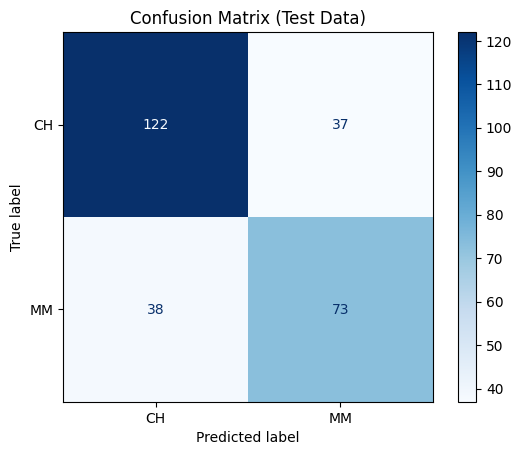

In [10]:
# Cell 5: (e) Test predictions, confusion matrix, and test error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on test data
test_pred = clf.predict(X_test)

# Calculate test error rate
test_error = 1 - accuracy_score(y_test, test_pred)
print(f"Test Error Rate: {test_error:.4f}")

# Plot confusion matrix
cm = confusion_matrix(y_test, test_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Test Data)")
plt.show()

In [11]:
# Cell 6: (f) Cross-validation using Cost Complexity Pruning
from sklearn.model_selection import KFold, GridSearchCV

# Extract alpha values for pruning
ccp_path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = ccp_path.ccp_alphas

# Set up 10-fold cross validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Set up GridSearchCV to test all alpha values
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), 
                    param_grid={'ccp_alpha': ccp_alphas}, 
                    cv=kfold, 
                    scoring='accuracy')

# Fit the grid search to find the optimal alpha
grid.fit(X_train, y_train)
print("Cross-validation completed.")

Cross-validation completed.


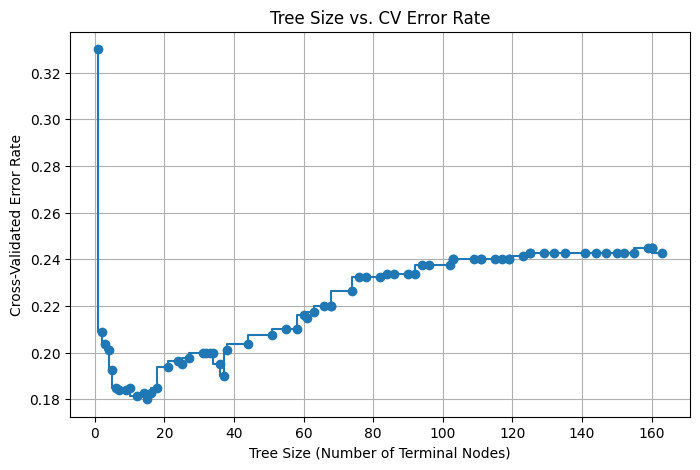

In [24]:
# Cell 7: (g) Plot Tree Size vs. CV Classification Error
import numpy as np

# Extract cross-validation accuracy results and convert to error rates
cv_results = pd.DataFrame(grid.cv_results_)
cv_errors = 1 - cv_results['mean_test_score']

# Determine the number of leaves for each alpha tested
tree_sizes = []
for alpha in ccp_alphas:
    temp_clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    temp_clf.fit(X_train, y_train)
    tree_sizes.append(temp_clf.get_n_leaves())

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(tree_sizes, cv_errors, marker='o', drawstyle="steps-post")
plt.xlabel('Tree Size (Number of Terminal Nodes)')
plt.ylabel('Cross-Validated Error Rate')
plt.title('Tree Size vs. CV Error Rate')
plt.grid(True)
plt.show()

In [25]:
# (h) Extract the optimal tree size
# Get the best estimator found by GridSearchCV
best_tree = grid.best_estimator_
optimal_size = best_tree.get_n_leaves()

print(f"The tree size with the lowest CV error rate is: {optimal_size} nodes.")

The tree size with the lowest CV error rate is: 15 nodes.


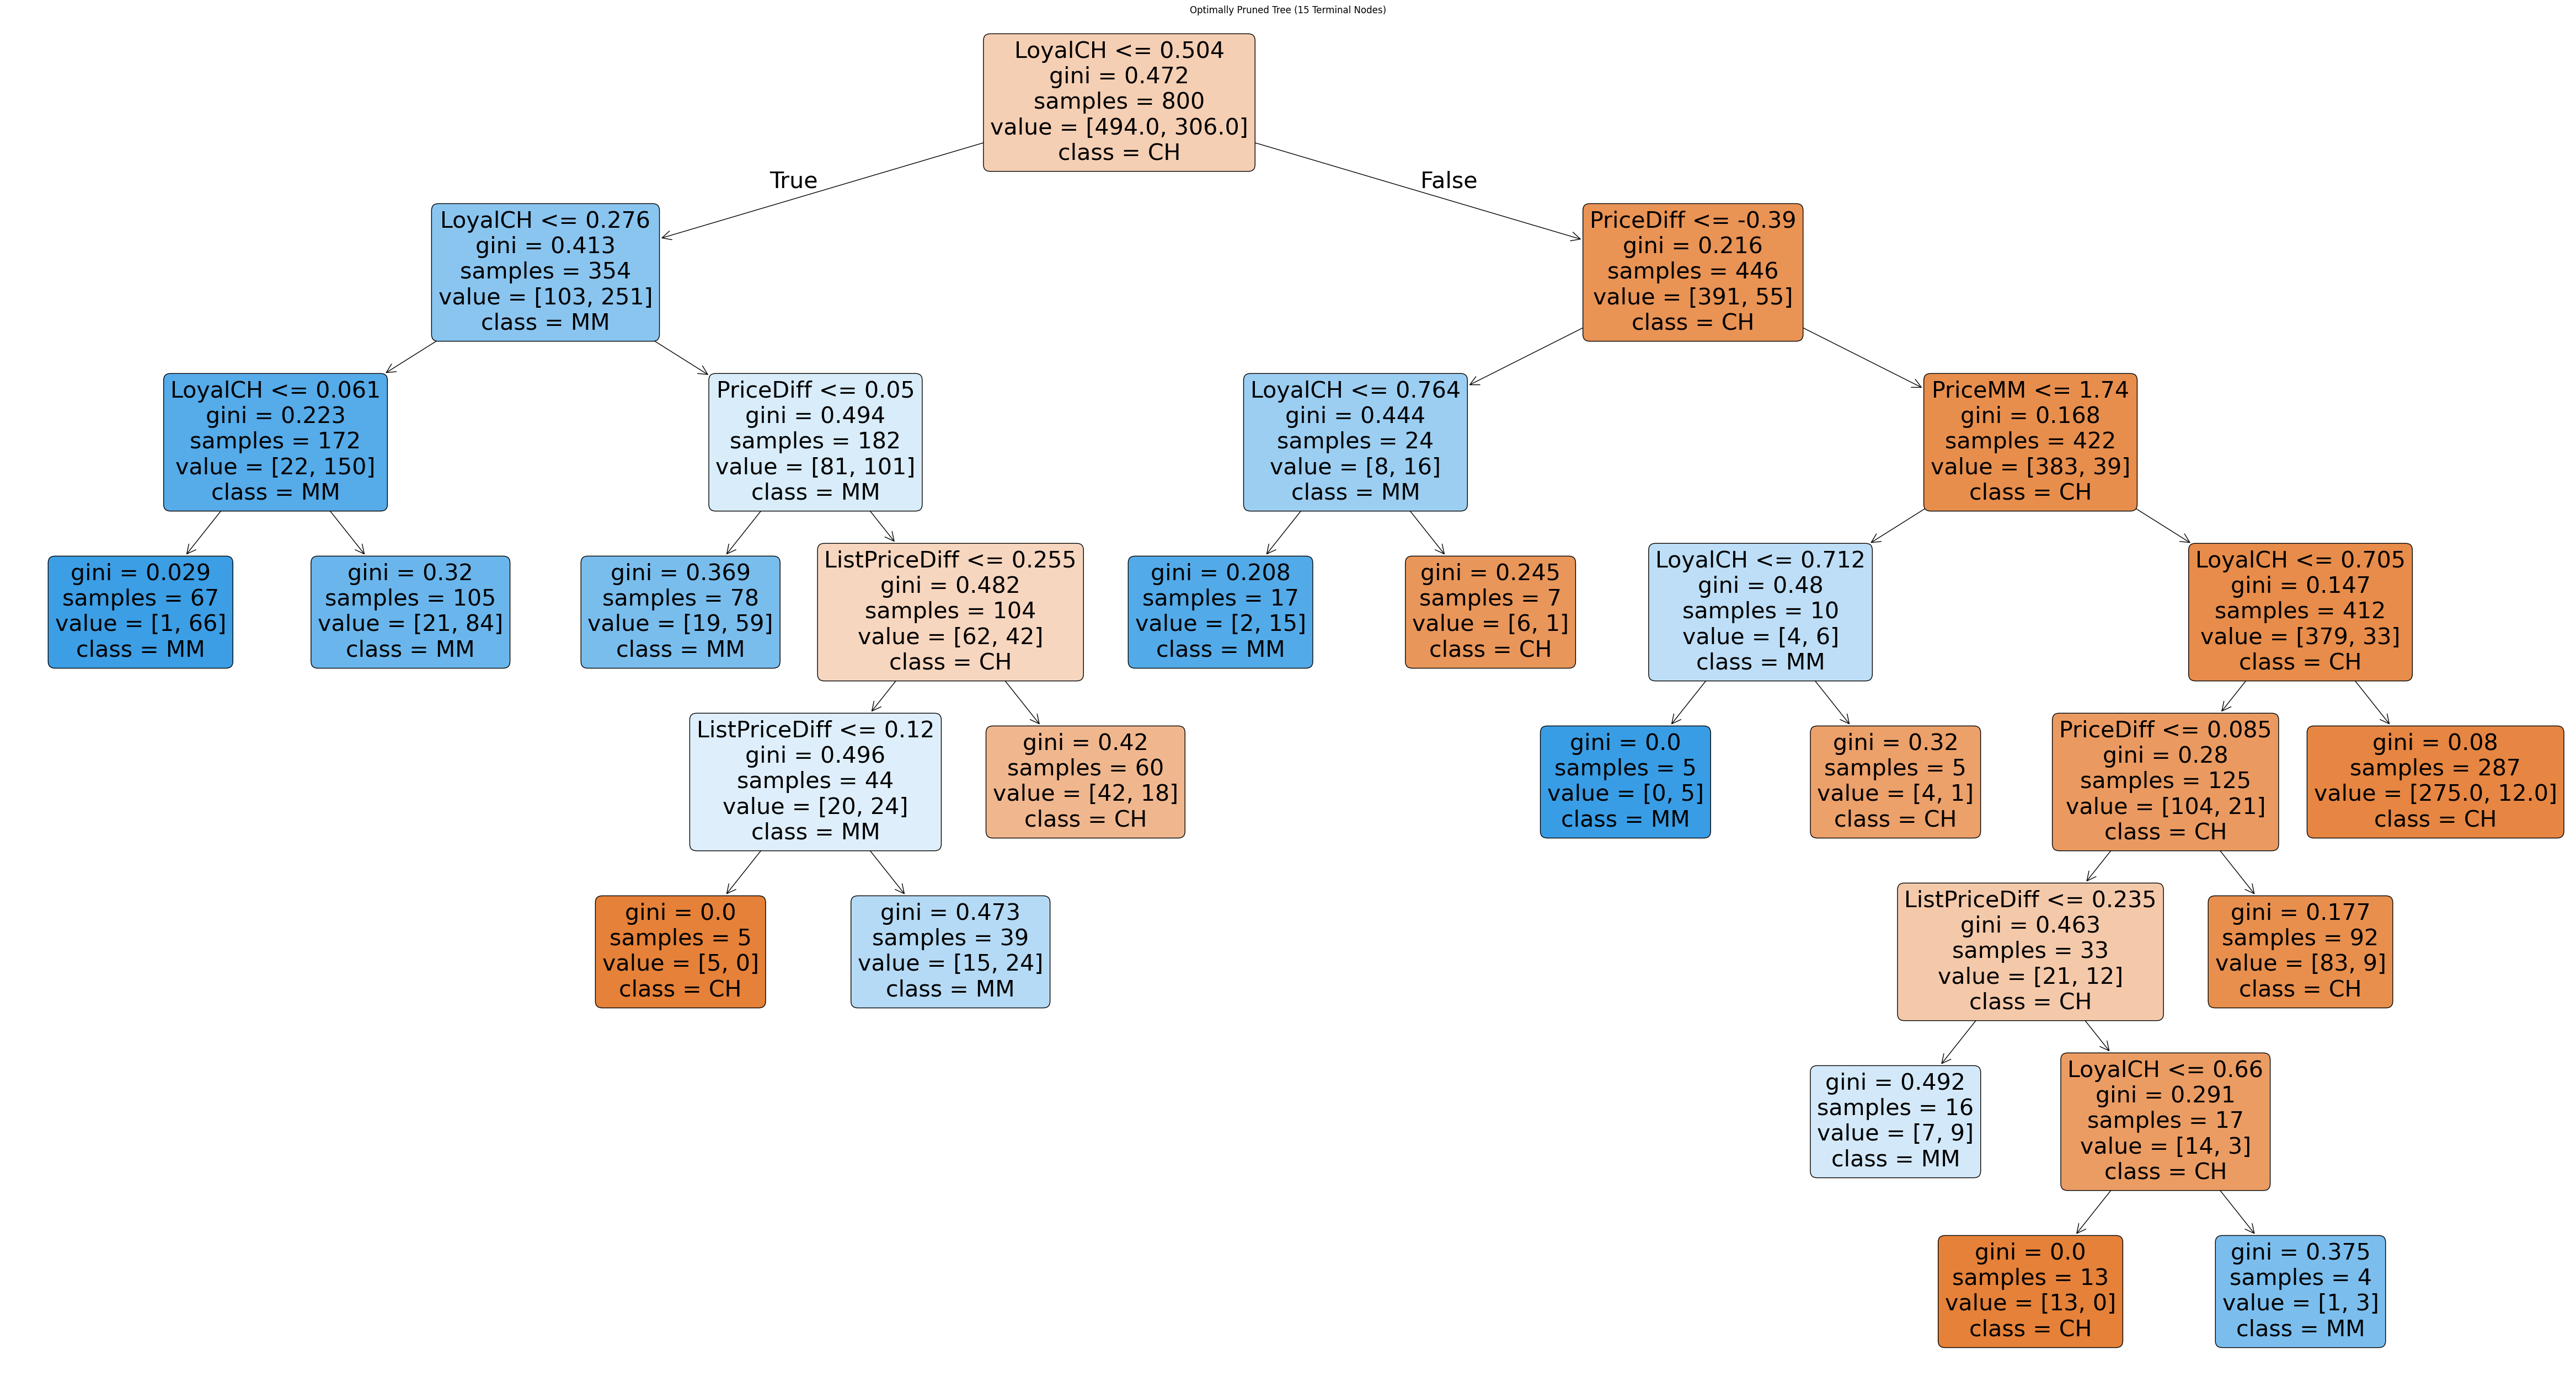

In [15]:
# (i) Plot the optimally pruned tree
# The 'best_tree' from part (h) is already our optimally pruned tree
plt.figure(figsize=(60, 32))
plot_tree(best_tree, feature_names=X.columns, class_names=clf.classes_, filled=True, rounded=True)
plt.title(f"Optimally Pruned Tree ({optimal_size} Terminal Nodes)")
plt.show()

In [26]:
# Cell 4: (d) Text summary using export_text
from sklearn.tree import export_text

# Generate the text representation of the tree
tree_text = export_text(best_tree, feature_names=list(X.columns))

# Print the first 1000 characters to avoid cluttering the notebook output
print("Tree Summary (Trunctuated):")
print(tree_text)


Tree Summary (Trunctuated):
|--- LoyalCH <= 0.50
|   |--- LoyalCH <= 0.28
|   |   |--- LoyalCH <= 0.06
|   |   |   |--- class: MM
|   |   |--- LoyalCH >  0.06
|   |   |   |--- class: MM
|   |--- LoyalCH >  0.28
|   |   |--- PriceDiff <= 0.05
|   |   |   |--- class: MM
|   |   |--- PriceDiff >  0.05
|   |   |   |--- ListPriceDiff <= 0.26
|   |   |   |   |--- ListPriceDiff <= 0.12
|   |   |   |   |   |--- class: CH
|   |   |   |   |--- ListPriceDiff >  0.12
|   |   |   |   |   |--- class: MM
|   |   |   |--- ListPriceDiff >  0.26
|   |   |   |   |--- class: CH
|--- LoyalCH >  0.50
|   |--- PriceDiff <= -0.39
|   |   |--- LoyalCH <= 0.76
|   |   |   |--- class: MM
|   |   |--- LoyalCH >  0.76
|   |   |   |--- class: CH
|   |--- PriceDiff >  -0.39
|   |   |--- PriceMM <= 1.74
|   |   |   |--- LoyalCH <= 0.71
|   |   |   |   |--- class: MM
|   |   |   |--- LoyalCH >  0.71
|   |   |   |   |--- class: CH
|   |   |--- PriceMM >  1.74
|   |   |   |--- LoyalCH <= 0.71
|   |   |   |   |--- PriceD

In [27]:
# Cell 10: (j) Compare training errors
# Calculate training error for the pruned tree
pruned_train_pred = best_tree.predict(X_train)
pruned_train_error = 1 - accuracy_score(y_train, pruned_train_pred)

print(f"Unpruned Tree Training Error: {train_error:.4f}")
print(f"Pruned Tree Training Error:   {pruned_train_error:.4f}")


Unpruned Tree Training Error: 0.0075
Pruned Tree Training Error:   0.1338


In [ ]:
# Cell 11: (k) Compare test errors
# Calculate test error for the pruned tree
pruned_test_pred = best_tree.predict(X_test)
pruned_test_error = 1 - accuracy_score(y_test, pruned_test_pred)

print(f"Unpruned Tree Test Error: {test_error:.4f}")
print(f"Pruned Tree Test Error:   {pruned_test_error:.4f}")

Unpruned Tree Test Error: 0.2778
Pruned Tree Test Error:   0.2444
